# Production Well Network Solver

This notebook demonstrates NeqSim's production well network extensions to the `LoopedPipeNetwork` solver.
These extensions add **well IPR models**, **choke valves**, and **vertical lift (tubing)** elements
alongside standard pipes, enabling integrated production network analysis.

## Generalized Network Elements

| Element | Head Loss Model | Parameters |
|---------|----------------|------------|
| **PIPE** | Darcy-Weisbach: $h_f = f \frac{L}{D} \frac{\rho v^2}{2}$ | Length, diameter, roughness |
| **WELL_IPR** | PI: $\Delta P = Q / PI$, Vogel, Fetkovich | Reservoir pressure, PI or C/n |
| **CHOKE** | Valve: $\Delta P = \left(\frac{Q}{K_v \cdot \text{opening}}\right)^2 \frac{1}{\rho}$ | K_v, opening % |
| **TUBING** | Gravity + friction: $\Delta P = \rho g L \sin\theta + f \frac{L}{D} \frac{\rho v^2}{2}$ | Inclination, length |
| **MULTIPHASE_PIPE** | Same as PIPE (simplified) | Length, diameter |

All elements are solved simultaneously using the **Newton-Raphson Global Gradient Algorithm** (Todini-Pilati, 1988).

## IPR Models

**Productivity Index (Oil):** $Q = PI \cdot (P_r - P_{wf})$

**Productivity Index (Gas):** $Q = PI \cdot (P_r^2 - P_{wf}^2)$

**Vogel:** $\frac{Q}{Q_{\max}} = 1 - 0.2\frac{P_{wf}}{P_r} - 0.8\left(\frac{P_{wf}}{P_r}\right)^2$

**Fetkovich:** $Q = C \cdot (P_r^2 - P_{wf}^2)^n$

In [3]:
# Setup NeqSim
import importlib, subprocess, sys
import jpype

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

import matplotlib.pyplot as plt
import numpy as np

# Get the LoopedPipeNetwork class
LoopedPipeNetwork = jpype.JClass("neqsim.process.equipment.network.LoopedPipeNetwork")
SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")

JVM already running — reusing existing JVM
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [4]:
# Create a gas fluid template (used for density and viscosity calculations)
gas = SystemSrkEos(273.15 + 40.0, 100.0)
gas.addComponent("methane", 0.90)
gas.addComponent("ethane", 0.06)
gas.addComponent("propane", 0.03)
gas.addComponent("nitrogen", 0.01)
gas.setMixingRule("classic")
print("Gas fluid template created (SRK EOS, 4 components)")

Gas fluid template created (SRK EOS, 4 components)


## Example 1: Single Well with PI Model

A single oil well connected to a separator.

```
Reservoir (300 bar) --> [IPR] --> Wellhead --> [Pipe 5km] --> Separator (50 bar)
```

PI = 5e-7 kg/s/Pa (~1.8 kg/s per bar drawdown, typical oil well)

In [5]:
net1 = LoopedPipeNetwork("Single well PI")
net1.setFluidTemplate(gas)
net1.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net1.setMaxIterations(200)
net1.setTolerance(100.0)

# Nodes
net1.addSourceNode("reservoir", 300.0, 0.0)      # Fixed pressure, 300 bara
net1.addJunctionNode("wellhead")                   # Free node
net1.addFixedPressureSinkNode("separator", 50.0)   # Fixed pressure, 50 bara

# Elements
net1.addWellIPR("reservoir", "wellhead", "ipr", 5e-7, False)  # Oil-type PI
net1.addPipe("wellhead", "separator", "flowline", 5000.0, 0.15)  # 5km, 6-inch

net1.run()

print(f"Converged: {net1.isConverged()} in {net1.getIterationCount()} iterations")
print(f"Wellhead pressure: {net1.getNodePressure('wellhead'):.1f} bara")
print(f"Production rate: {net1.getPipeFlowRate('ipr'):.0f} kg/hr")
print(f"IPR drawdown: {300.0 - net1.getNodePressure('wellhead'):.1f} bar")
print(f"Flowline dP: {net1.getNodePressure('wellhead') - 50.0:.1f} bar")

Converged: True in 14 iterations
Wellhead pressure: 64.0 bara
Production rate: 42482 kg/hr
IPR drawdown: 236.0 bar
Flowline dP: 14.0 bar


## Example 2: Vogel IPR — Oil Well Below Bubble Point

The Vogel correlation is used for oil wells producing below the bubble point, where
two-phase flow effects reduce productivity:

$$\frac{Q}{Q_{\max}} = 1 - 0.2\frac{P_{wf}}{P_r} - 0.8\left(\frac{P_{wf}}{P_r}\right)^2$$

In [6]:
net2 = LoopedPipeNetwork("Vogel well")
net2.setFluidTemplate(gas)
net2.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net2.setMaxIterations(200)
net2.setTolerance(100.0)

net2.addSourceNode("reservoir", 250.0, 0.0)
net2.addJunctionNode("wellhead")
net2.addFixedPressureSinkNode("separator", 30.0)

# Vogel: qmax = 50 kg/s (maximum production at Pwf=0)
net2.addWellIPRVogel("reservoir", "wellhead", "ipr_vogel", 50.0)
net2.addPipe("wellhead", "separator", "flowline", 3000.0, 0.20)

net2.run()

pWh = net2.getNodePressure("wellhead")
flow = net2.getPipeFlowRate("ipr_vogel")

print(f"Converged: {net2.isConverged()}")
print(f"Wellhead P = {pWh:.1f} bara")
print(f"Production = {flow:.0f} kg/hr ({flow/3600:.1f} kg/s)")
print(f"Drawdown = {250.0 - pWh:.1f} bar")
print(f"Q/Qmax = {flow/3600/50*100:.1f}%")

Converged: True
Wellhead P = 57.8 bara
Production = 163978 kg/hr (45.5 kg/s)
Drawdown = 192.2 bar
Q/Qmax = 91.1%


## Example 3: IPR Curve Comparison

Compare production rates from the same well using different IPR models by
varying separator (backpressure) and observing how production changes.

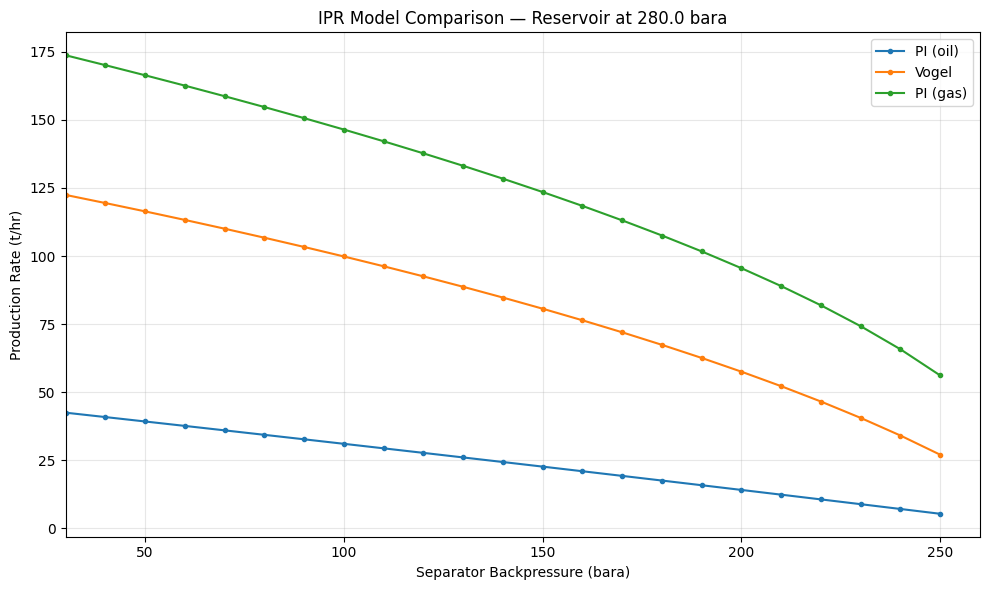

In [7]:
sep_pressures = np.arange(30, 260, 10)  # bara
p_res = 280.0

results = {"PI (oil)": [], "Vogel": [], "PI (gas)": []}

for p_sep in sep_pressures:
    for model_name, setup_fn in [
        ("PI (oil)", lambda n: n.addWellIPR("res", "wh", "ipr", 5e-7, False)),
        ("Vogel", lambda n: n.addWellIPRVogel("res", "wh", "ipr", 50.0)),
        ("PI (gas)", lambda n: n.addWellIPR("res", "wh", "ipr", 5e-13, True)),
    ]:
        net = LoopedPipeNetwork(model_name)
        net.setFluidTemplate(gas)
        net.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
        net.setMaxIterations(300)
        net.setTolerance(500.0)

        net.addSourceNode("res", p_res, 0.0)
        net.addJunctionNode("wh")
        net.addFixedPressureSinkNode("sep", float(p_sep))
        setup_fn(net)
        net.addPipe("wh", "sep", "line", 5000.0, 0.15)

        net.run()
        if net.isConverged():
            results[model_name].append(net.getPipeFlowRate("ipr"))
        else:
            results[model_name].append(float('nan'))

fig, ax = plt.subplots(figsize=(10, 6))
for name, flows in results.items():
    ax.plot(sep_pressures, [f/1000 for f in flows], 'o-', label=name, markersize=3)
ax.set_xlabel("Separator Backpressure (bara)")
ax.set_ylabel("Production Rate (t/hr)")
ax.set_title(f"IPR Model Comparison — Reservoir at {p_res} bara")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(30, 260)
plt.tight_layout()
plt.savefig("ipr_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussion

The PI (oil) model gives a linear relationship between backpressure and production.
The Vogel model shows sub-linear behavior at high drawdowns due to two-phase flow effects.
The PI (gas) model uses $P_r^2 - P_{wf}^2$ which gives different curvature.
All models converge to zero production as separator pressure approaches reservoir pressure.

## Example 4: Choke Sensitivity Analysis

Varying the choke opening from 25% to 100% to see the effect on production rate.

```
Reservoir (300 bar) --> [IPR] --> WH --> [Choke] --> DS --> [Pipe] --> Sep (50 bar)
```

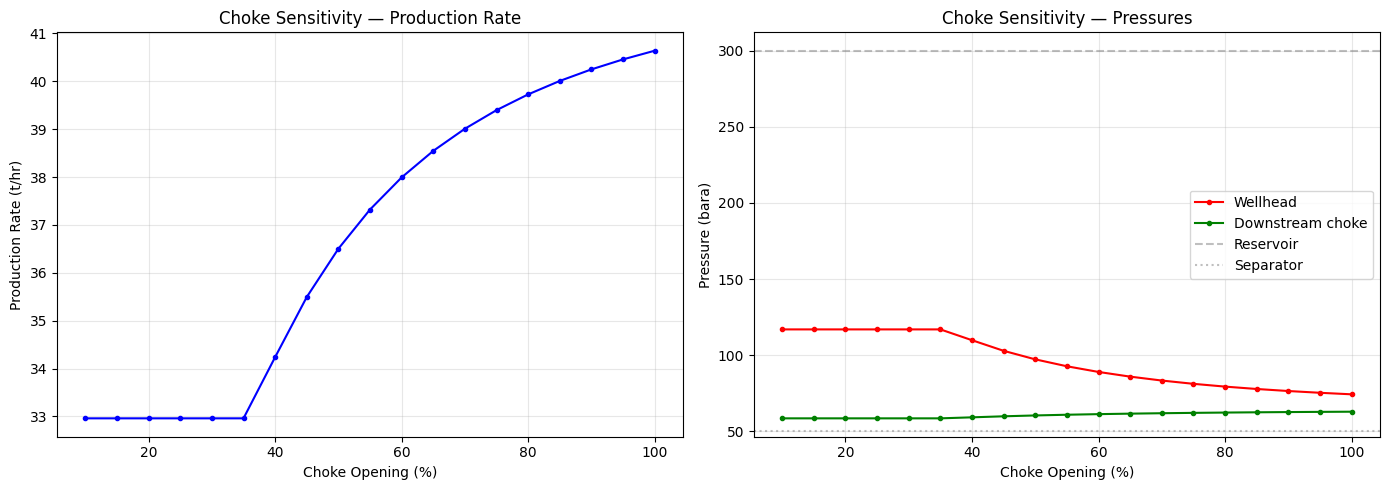

In [8]:
openings = np.arange(10, 105, 5)
choke_flows = []
choke_wh_pressures = []
choke_ds_pressures = []

for opening in openings:
    net = LoopedPipeNetwork(f"choke_{opening}")
    net.setFluidTemplate(gas)
    net.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
    net.setMaxIterations(500)
    net.setTolerance(500.0)

    net.addSourceNode("reservoir", 300.0, 0.0)
    net.addJunctionNode("wellhead")
    net.addJunctionNode("ds_choke")
    net.addFixedPressureSinkNode("separator", 50.0)

    net.addWellIPR("reservoir", "wellhead", "ipr", 5e-7, False)
    net.addChoke("wellhead", "ds_choke", "choke", 150.0, float(opening))
    net.addPipe("ds_choke", "separator", "line", 5000.0, 0.15)

    net.run()
    if net.isConverged():
        choke_flows.append(net.getPipeFlowRate("ipr"))
        choke_wh_pressures.append(net.getNodePressure("wellhead"))
        choke_ds_pressures.append(net.getNodePressure("ds_choke"))
    else:
        choke_flows.append(float('nan'))
        choke_wh_pressures.append(float('nan'))
        choke_ds_pressures.append(float('nan'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Flow vs opening
ax1.plot(openings, [f/1000 for f in choke_flows], 'b-o', markersize=3)
ax1.set_xlabel("Choke Opening (%)")
ax1.set_ylabel("Production Rate (t/hr)")
ax1.set_title("Choke Sensitivity — Production Rate")
ax1.grid(True, alpha=0.3)

# Right: Pressure profile
ax2.plot(openings, choke_wh_pressures, 'r-o', label="Wellhead", markersize=3)
ax2.plot(openings, choke_ds_pressures, 'g-o', label="Downstream choke", markersize=3)
ax2.axhline(y=300.0, color='gray', linestyle='--', alpha=0.5, label="Reservoir")
ax2.axhline(y=50.0, color='gray', linestyle=':', alpha=0.5, label="Separator")
ax2.set_xlabel("Choke Opening (%)")
ax2.set_ylabel("Pressure (bara)")
ax2.set_title("Choke Sensitivity — Pressures")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("choke_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussion

As choke opening increases, more flow passes with less pressure drop across the choke.
Wellhead pressure decreases (more IPR drawdown) while downstream pressure increases.
At 100% opening, the choke provides minimal restriction. At low openings, the choke
dominates the system pressure drop, significantly reducing production.

## Example 5: Complete Well System

Full well path: reservoir to separator through IPR, tubing, choke, and flowline.

```
Reservoir (400 bar) --> [IPR] --> BH --> [Tubing 3500m] --> WH --> [Choke 70%] --> DS --> [Pipe 8km] --> Sep (40 bar)
```

Converged: True in 18 iterations

Pressure Profile:
  Reservoir = 400 bara
  Bottomhole = 391.2 bara  (IPR drawdown = 8.8 bar)
  Wellhead   = 111.3 bara  (Tubing dP = 279.9 bar)
  DS Choke   = 55.7 bara  (Choke dP = 55.7 bar)
  Separator  = 40 bara   (Flowline dP = 15.7 bar)

Production rate = 75174 kg/hr (20.88 kg/s)


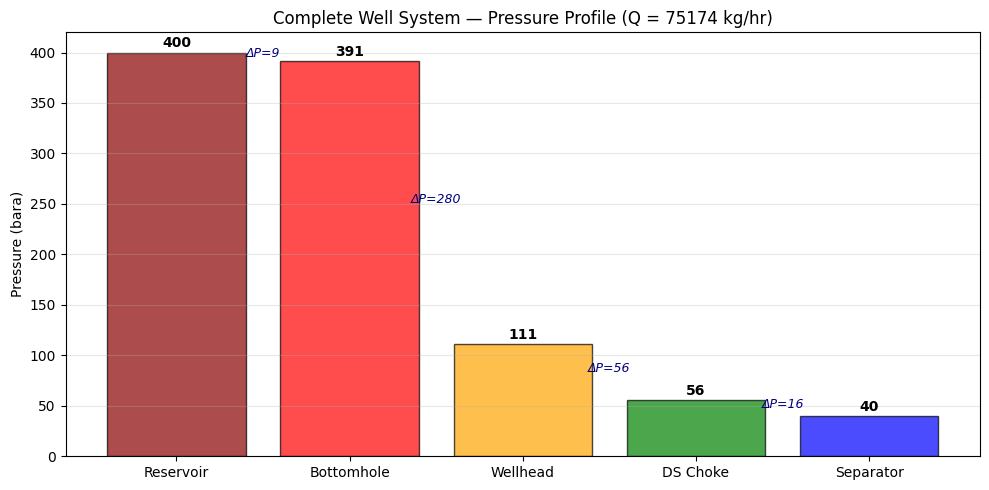

In [9]:
net5 = LoopedPipeNetwork("complete well")
net5.setFluidTemplate(gas)
net5.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net5.setMaxIterations(500)
net5.setTolerance(500.0)

# Full well path nodes
net5.addSourceNode("reservoir", 400.0, 0.0)
net5.addJunctionNode("BH")     # Bottomhole
net5.addJunctionNode("WH")     # Wellhead
net5.addJunctionNode("DS")     # Downstream of choke
net5.addFixedPressureSinkNode("separator", 40.0)

# Elements
net5.addWellIPR("reservoir", "BH", "ipr", 3e-13, True)           # Gas IPR
net5.addTubing("BH", "WH", "tubing", 3500.0, 0.10, 85.0)         # Near-vertical tubing
net5.addChoke("WH", "DS", "choke", 150.0, 70.0)                   # 70% open choke
net5.addPipe("DS", "separator", "flowline", 8000.0, 0.20)         # 8km flowline

net5.run()

p_res = 400.0
p_bh = net5.getNodePressure("BH")
p_wh = net5.getNodePressure("WH")
p_ds = net5.getNodePressure("DS")
p_sep = 40.0
rate = net5.getPipeFlowRate("ipr")

print(f"Converged: {net5.isConverged()} in {net5.getIterationCount()} iterations")
print(f"\nPressure Profile:")
print(f"  Reservoir = {p_res:.0f} bara")
print(f"  Bottomhole = {p_bh:.1f} bara  (IPR drawdown = {p_res - p_bh:.1f} bar)")
print(f"  Wellhead   = {p_wh:.1f} bara  (Tubing dP = {p_bh - p_wh:.1f} bar)")
print(f"  DS Choke   = {p_ds:.1f} bara  (Choke dP = {p_wh - p_ds:.1f} bar)")
print(f"  Separator  = {p_sep:.0f} bara   (Flowline dP = {p_ds - p_sep:.1f} bar)")
print(f"\nProduction rate = {rate:.0f} kg/hr ({rate/3600:.2f} kg/s)")

# Pressure profile plot
fig, ax = plt.subplots(figsize=(10, 5))
locations = ["Reservoir", "Bottomhole", "Wellhead", "DS Choke", "Separator"]
pressures = [p_res, p_bh, p_wh, p_ds, p_sep]
colors = ['darkred', 'red', 'orange', 'green', 'blue']

ax.bar(locations, pressures, color=colors, alpha=0.7, edgecolor='black')
for i, (loc, p) in enumerate(zip(locations, pressures)):
    ax.text(i, p + 5, f"{p:.0f}", ha='center', fontweight='bold')

# Annotate pressure drops
for i in range(len(pressures)-1):
    dp = pressures[i] - pressures[i+1]
    mid = (pressures[i] + pressures[i+1]) / 2
    ax.annotate(f"\u0394P={dp:.0f}", xy=(i+0.5, mid), ha='center',
                fontsize=9, color='navy', fontstyle='italic')

ax.set_ylabel("Pressure (bara)")
ax.set_title(f"Complete Well System — Pressure Profile (Q = {rate:.0f} kg/hr)")
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("well_pressure_profile.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussion

The pressure profile shows monotonic decrease from reservoir to separator.
The IPR provides the largest drawdown, followed by the choke and tubing gravity head.
The flowline has relatively low pressure drop for this pipe diameter.

## Example 6: Multi-Well Gathering Network

Two wells with different reservoir pressures and choke settings, connected through
a common manifold to a single export pipeline.

```
Res1 (350 bar) --> [IPR1] --> WH1 --> [Choke 80%] --> DS1 --+
                                                             +--> Manifold --> [Export 10km] --> Sep (50 bar)
Res2 (280 bar) --> [IPR2] --> WH2 --> [Choke 60%] --> DS2 --+
```

In [10]:
net6 = LoopedPipeNetwork("multi-well gathering")
net6.setFluidTemplate(gas)
net6.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net6.setMaxIterations(500)
net6.setTolerance(500.0)

# Two reservoirs
net6.addSourceNode("res1", 350.0, 0.0)
net6.addSourceNode("res2", 280.0, 0.0)

# Wellheads and downstream choke nodes
net6.addJunctionNode("wh1")
net6.addJunctionNode("wh2")
net6.addJunctionNode("ds1")
net6.addJunctionNode("ds2")
net6.addJunctionNode("manifold")
net6.addFixedPressureSinkNode("separator", 50.0)

# Well 1: Higher pressure, higher PI
net6.addWellIPR("res1", "wh1", "ipr1", 8e-13, True)  # Gas IPR
net6.addChoke("wh1", "ds1", "choke1", 150.0, 80.0)   # 80% open
net6.addPipe("ds1", "manifold", "pipe1", 2000.0, 0.15)

# Well 2: Lower pressure, lower PI
net6.addWellIPR("res2", "wh2", "ipr2", 5e-13, True)  # Gas IPR
net6.addChoke("wh2", "ds2", "choke2", 150.0, 60.0)   # 60% open
net6.addPipe("ds2", "manifold", "pipe2", 3000.0, 0.15)

# Export pipeline
net6.addPipe("manifold", "separator", "export", 10000.0, 0.25)

net6.run()

print(f"Converged: {net6.isConverged()} in {net6.getIterationCount()} iterations")
print(f"\nWell 1: Q={net6.getPipeFlowRate('ipr1'):.0f} kg/hr, WHP={net6.getNodePressure('wh1'):.1f} bara")
print(f"Well 2: Q={net6.getPipeFlowRate('ipr2'):.0f} kg/hr, WHP={net6.getNodePressure('wh2'):.1f} bara")
print(f"Manifold P = {net6.getNodePressure('manifold'):.1f} bara")
print(f"Export: {net6.getPipeFlowRate('export'):.0f} kg/hr")
print(f"Total production: {net6.getPipeFlowRate('ipr1') + net6.getPipeFlowRate('ipr2'):.0f} kg/hr")

Converged: True in 26 iterations

Well 1: Q=145250 kg/hr, WHP=342.7 bara
Well 2: Q=83251 kg/hr, WHP=271.6 bara
Manifold P = 106.4 bara
Export: 228501 kg/hr
Total production: 228501 kg/hr


## Example 7: Choke Allocation Optimization

For the multi-well network, sweep the choke opening of Well 2 while keeping Well 1 at 80%,
to find the optimal allocation that maximizes total production.

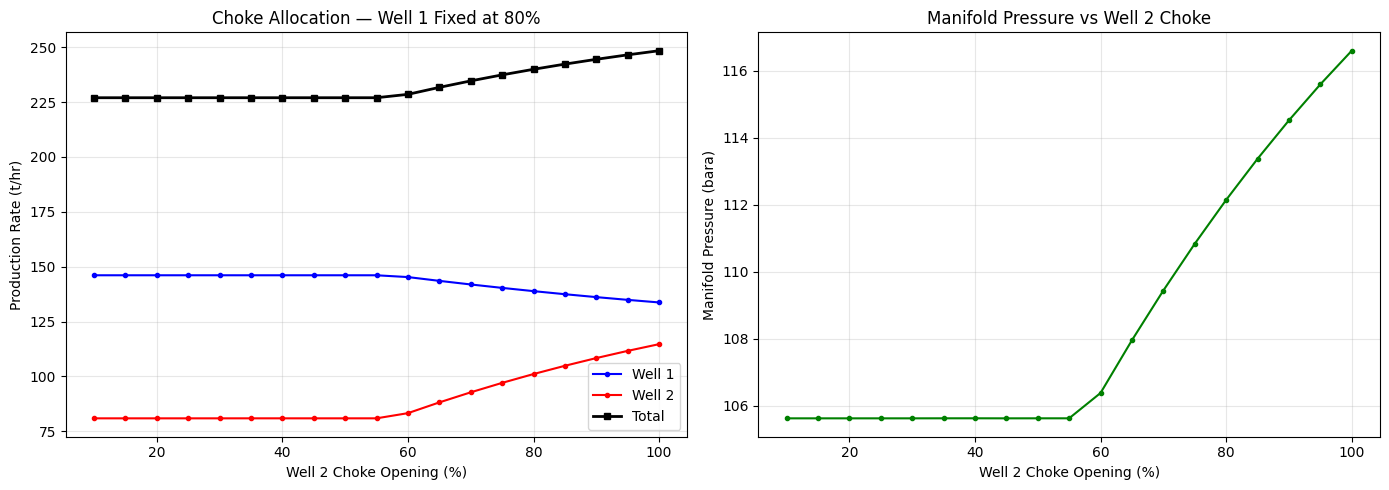


Optimal Well 2 opening: 100%
Max total production: 248.4 t/hr


In [11]:
openings_w2 = np.arange(10, 105, 5)
total_production = []
well1_rates = []
well2_rates = []
manifold_pressures = []

for opening in openings_w2:
    net = LoopedPipeNetwork(f"alloc_{opening}")
    net.setFluidTemplate(gas)
    net.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
    net.setMaxIterations(500)
    net.setTolerance(500.0)

    net.addSourceNode("res1", 350.0, 0.0)
    net.addSourceNode("res2", 280.0, 0.0)
    net.addJunctionNode("wh1")
    net.addJunctionNode("wh2")
    net.addJunctionNode("ds1")
    net.addJunctionNode("ds2")
    net.addJunctionNode("manifold")
    net.addFixedPressureSinkNode("separator", 50.0)

    net.addWellIPR("res1", "wh1", "ipr1", 8e-13, True)
    net.addChoke("wh1", "ds1", "choke1", 150.0, 80.0)  # Well 1 fixed at 80%
    net.addPipe("ds1", "manifold", "pipe1", 2000.0, 0.15)

    net.addWellIPR("res2", "wh2", "ipr2", 5e-13, True)
    net.addChoke("wh2", "ds2", "choke2", 150.0, float(opening))  # Well 2 varied
    net.addPipe("ds2", "manifold", "pipe2", 3000.0, 0.15)

    net.addPipe("manifold", "separator", "export", 10000.0, 0.25)

    net.run()
    if net.isConverged():
        q1 = net.getPipeFlowRate("ipr1")
        q2 = net.getPipeFlowRate("ipr2")
        well1_rates.append(q1)
        well2_rates.append(q2)
        total_production.append(q1 + q2)
        manifold_pressures.append(net.getNodePressure("manifold"))
    else:
        well1_rates.append(float('nan'))
        well2_rates.append(float('nan'))
        total_production.append(float('nan'))
        manifold_pressures.append(float('nan'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Production rates
ax1.plot(openings_w2, [f/1000 for f in well1_rates], 'b-o', label="Well 1", markersize=3)
ax1.plot(openings_w2, [f/1000 for f in well2_rates], 'r-o', label="Well 2", markersize=3)
ax1.plot(openings_w2, [f/1000 for f in total_production], 'k-s', label="Total", markersize=4, linewidth=2)
ax1.set_xlabel("Well 2 Choke Opening (%)")
ax1.set_ylabel("Production Rate (t/hr)")
ax1.set_title("Choke Allocation — Well 1 Fixed at 80%")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Manifold pressure
ax2.plot(openings_w2, manifold_pressures, 'g-o', markersize=3)
ax2.set_xlabel("Well 2 Choke Opening (%)")
ax2.set_ylabel("Manifold Pressure (bara)")
ax2.set_title("Manifold Pressure vs Well 2 Choke")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("choke_allocation.png", dpi=150, bbox_inches="tight")
plt.show()

# Find optimal
best_idx = np.nanargmax(total_production)
print(f"\nOptimal Well 2 opening: {openings_w2[best_idx]}%")
print(f"Max total production: {total_production[best_idx]/1000:.1f} t/hr")

### Discussion

Opening Well 2's choke increases Well 2's production but also raises manifold pressure,
which can reduce Well 1's production (backpressure effect). The network coupling means
optimal total production requires balancing both wells — not simply opening all chokes fully.
This demonstrates why integrated network modeling is essential for production optimization.

## Example 8: Solution Summary and Element Inspection

Access the detailed solution data including element types, flow regimes, and hydraulic parameters.

In [12]:
# Use the multi-well network from Example 6
summary = str(net6.getSolutionSummary())
print(summary[:2000])  # Print first 2000 chars of the summary

{pipeFlowRates_kghr={choke1=145250.07435442656, choke2=83251.00489654539, ipr2=83251.00489654539, ipr1=145250.07435442656, pipe1=145250.07435442656, export=228501.07925097196, pipe2=83251.00489654539}, numberOfLoops=0, converged=true, nodePressures_bara={wh2=271.6154343413022, wh1=342.7194109478971, ds2=138.47268331698373, ds1=171.36083845821514, res1=350.0, res2=280.0, manifold=106.38306864739795, separator=50.0}, numberOfPipes=7, massBalanceError_kgs=0.0, networkName=multi-well gathering, maxResidual_Pa=240.70021600276232, numberOfNodes=8, solverType=NEWTON_RAPHSON, iterations=26, tolerance_Pa=500.0}


In [13]:
# Access individual pipe/element properties
print("Element Types:")
for name in ["ipr1", "choke1", "pipe1", "ipr2", "choke2", "pipe2", "export"]:
    pipe = net6.getPipe(name)
    etype = str(pipe.getElementType())
    flow = pipe.getFlowRate() * 3600  # kg/s to kg/hr
    hl = pipe.getHeadLoss() / 1e5  # Pa to bar
    regime = str(pipe.getFlowRegime()) if pipe.getFlowRegime() else "N/A"
    print(f"  {name:10s}: type={etype:15s}, flow={flow:10.0f} kg/hr, dP={hl:8.1f} bar, regime={regime}")

Element Types:
  ipr1      : type=WELL_IPR       , flow=    145250 kg/hr, dP=     7.3 bar, regime=IPR-PRODUCTIVITY_INDEX
  choke1    : type=CHOKE          , flow=    145250 kg/hr, dP=   171.4 bar, regime=Choked
  pipe1     : type=PIPE           , flow=    145250 kg/hr, dP=    65.0 bar, regime=Turbulent
  ipr2      : type=WELL_IPR       , flow=     83251 kg/hr, dP=     8.4 bar, regime=IPR-PRODUCTIVITY_INDEX
  choke2    : type=CHOKE          , flow=     83251 kg/hr, dP=   133.1 bar, regime=Subcritical
  pipe2     : type=PIPE           , flow=     83251 kg/hr, dP=    32.1 bar, regime=Turbulent
  export    : type=PIPE           , flow=    228501 kg/hr, dP=    56.4 bar, regime=Turbulent


## Summary

The production network solver extends the NR-GGA method to handle:

1. **Well IPR models** (PI, Vogel, Fetkovich) — reservoir inflow performance
2. **Choke valves** — production throttling with Kv-based valve equation
3. **Tubing** — vertical lift with gravity and friction
4. **Standard pipes** — Darcy-Weisbach friction

All elements are solved simultaneously in a single coupled system, capturing:
- Well-to-well backpressure interactions
- Choke-manifold-pipeline coupling
- Optimal production allocation

### References

- Todini & Pilati (1988). A gradient algorithm for the analysis of pipe networks. *Computer Applications in Water Supply*.
- Vogel (1968). Inflow Performance Relationships for Solution-Gas Drive Wells. *JPT*.
- Fetkovich (1973). The Isochronal Testing of Oil Wells. *SPE 4529*.
- Brill & Mukherjee (1999). *Multiphase Flow in Wells*. SPE Monograph.